In [293]:
import sys
import os

sys.path.append(os.path.abspath('./bin')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.crs as ccrs

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [294]:
ssplist = ["126","245","370","585"]

ssplistplot = ["hist","126","245","370","585"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1950,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1970,2025]
baselineera_obs = [1940,1970]

inputlength = 10
outputavgtime = 10

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

device = 'mps'


data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [295]:
imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)

In [296]:
obsnull = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsnull_logistic = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsaccuracy = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

obsfirstpositive = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

allbaselines = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
baseline_percentile = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

ntruepositives = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
nfalsepositives = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

for ilat,lat in enumerate(AllObs.output_lat):

    for ilon,lon in enumerate(AllObs.output_lon):

        metricsout = "metrics/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(lat)+"_lon"+str(lon)+"_seed*.json"
        filelist = glob.glob(metricsout)

        # testmetricsout = "metrics/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(lat)+"_lon"+str(lon)+"_testing.json"

        if len(filelist)!=0:
            print('models exist, proceeding')

            bestseeds = helpers.get_best_files(filelist,n_best)
            obsinput,obsinputgmt,obsoutput = AllObs.obs_recordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)

            obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
            obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)

            print(bestseeds)
            obsnull[ilat,ilon] = max(1-np.mean(obsoutput),np.mean(obsoutput))
            obsnull_logistic[ilat,ilon] = 1-np.mean(obsoutput)

            obspredall = np.empty((3,len(obsinputgmt)))

            for iseed,seed in enumerate(bestseeds):
                # load the model

                loadfile = "models/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(lat)+"_lon"+str(lon)+"_seed"+str(seed)+".pt"
                cnn = buildmodel.CNNclassifier(obsinput_t, obsinputgmt_t, 2).to('cpu')
                cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
                cnn.to(device)

                with torch.no_grad():
                    cnn.eval()
                    obspred = cnn(obsinput_t.to(device), obsinputgmt_t.to(device)).cpu().numpy()

                obspredall[iseed] = obspred[:,1]

            obspredavg = np.mean(obspredall,axis=0)
            obspredclass = np.round(obspredavg)

            obsaccuracy[ilat,ilon] = np.mean(obsoutput==obspredclass)
            obsfirstpositive[ilat,ilon] = helpers.firstpositive(obspredavg,obsinputgmt)

            ntruepositives[ilat,ilon] = np.sum(1*((obsoutput==obspredclass) & (obsoutput==1)))
            nfalsepositives[ilat,ilon] = np.sum(1*((obsoutput!=obspredclass) & (obspredclass==1)))

            allbaselines[ilat,ilon] = AllObs.baseline
            baseline_percentile[ilat,ilon] = AllObs.baselinepercentile

        else:
            print('no model for '+ str(lat) + ' ' + str(lon))



no model for -90 0
no model for -90 10
no model for -90 20
no model for -90 30
no model for -90 40
no model for -90 50
no model for -90 60
no model for -90 70
no model for -90 80
no model for -90 90
no model for -90 100
no model for -90 110
no model for -90 120
no model for -90 130
no model for -90 140
no model for -90 150
no model for -90 160
no model for -90 170
no model for -90 180
no model for -90 190
no model for -90 200
no model for -90 210
no model for -90 220
no model for -90 230
no model for -90 240
no model for -90 250
no model for -90 260
no model for -90 270
no model for -90 280
no model for -90 290
no model for -90 300
no model for -90 310
no model for -90 320
no model for -90 330
no model for -90 340
no model for -90 350
no model for -80 0
no model for -80 10
no model for -80 20
no model for -80 30
no model for -80 40
no model for -80 50
no model for -80 60
no model for -80 70
no model for -80 80
no model for -80 90
no model for -80 100
no model for -80 110
no model for -

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_11394/1236788898.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


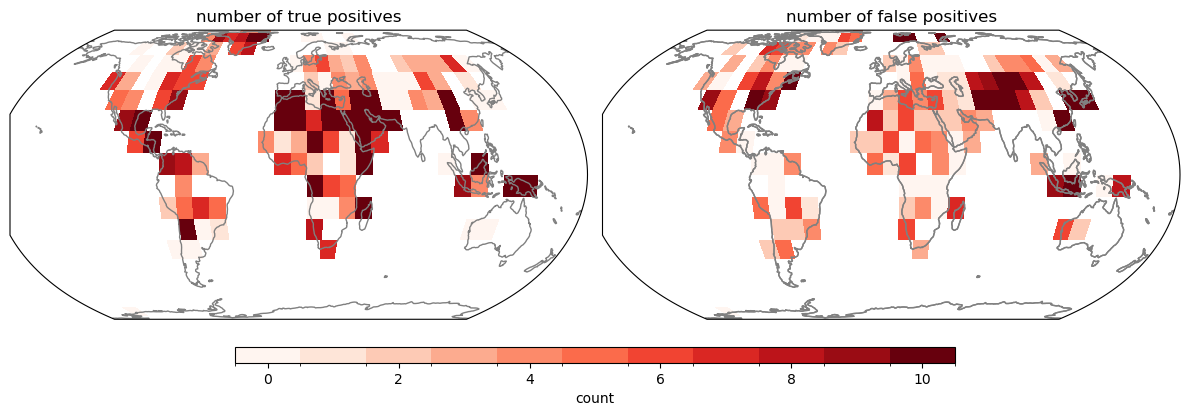

In [297]:
levsacc = np.linspace(0,1,21)
cmapacc = plt.get_cmap("Reds")

normacc = BoundaryNorm(levsacc,cmapacc.N)

diff1 = np.linspace(-0.2,0.2,21)
cmapdiff1 = plt.get_cmap("RdBu_r")
normdiff = BoundaryNorm(diff1,cmapdiff1.N)

diffper = np.linspace(-10.5,10.5,22)
cmapdiffper = plt.get_cmap("RdBu_r")
normdiffper = BoundaryNorm(diffper,cmapdiffper.N)

obsgain = obsaccuracy-obsnull_logistic
obsgain[np.isnan(obsfirstpositive)] = np.nan

levscount = np.linspace(-0.5,10.5,12)
normcount = BoundaryNorm(levscount,cmapacc.N)

# plt.figure(figsize=(12,5))

# ax=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
# ax.pcolormesh(lonvec+5,latvec+5,obsnull_logistic,norm=normacc,cmap='Reds',transform=ccrs.PlateCarree())
# ax.coastlines(color='gray')

# ax=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
# ax.pcolormesh(lonvec+5,latvec+5,obsaccuracy,norm=normacc,cmap='Reds',transform=ccrs.PlateCarree())
# ax.coastlines(color='gray')

# plt.tight_layout()

ntruepositives[np.isnan(obsfirstpositive)]=np.nan
nfalsepositives[np.isnan(obsfirstpositive)]=np.nan

plt.figure(figsize=(12,4))

ax=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
c7=ax.pcolormesh(lonvec+5,latvec+5,ntruepositives,cmap="Reds",norm=normcount,transform=ccrs.PlateCarree())
ax.coastlines(color='gray')
plt.title('number of true positives')

ax=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
c7=ax.pcolormesh(lonvec+5,latvec+5,nfalsepositives,cmap="Reds",norm=normcount,transform=ccrs.PlateCarree())
ax.coastlines(color='gray')
plt.title('number of false positives')

cax = plt.axes((0.2,0.03,0.6,0.04))
cbar = plt.colorbar(c7,cax,orientation='horizontal',ticks=np.arange(0,12,2))
cbar.ax.set_xlabel('count')

# ax=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
# ax.pcolormesh(lonvec+5,latvec+5,100*(obsaccuracy-obsnull_logistic)/obsnull_logistic,norm=normdiffper,cmap="RdBu_r",transform=ccrs.PlateCarree())

ax.coastlines(color='gray')
plt.tight_layout()

Text(0.5, 0, 'GMT anomaly from 1960-1990')

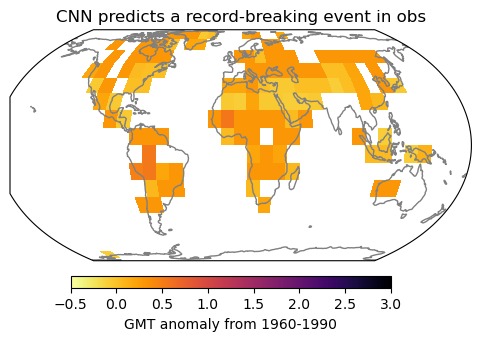

In [298]:
plt.figure(figsize=(8,3))

ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,obsfirstpositive,vmin=-0.5,vmax=3,cmap='inferno_r',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

plt.title("CNN predicts a record-breaking event in obs")

cax = plt.axes((0.3,0.02,0.4,0.04))
cbar = plt.colorbar(c1,cax,orientation='horizontal')
cbar.ax.set_xlabel('GMT anomaly from 1960-1990')


In [299]:
# select a gridpoint

latsel = 40
lonsel = 240

metricsout = "metrics/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

if len(filelist)!=0:
    print('models exist, proceeding')

    bestseeds = helpers.get_best_files(filelist,n_best)
    obsinput,obsinputgmt,obsoutput = AllObs.obs_recordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

    obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
    obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)

    print(bestseeds)
    obsnull[ilat,ilon] = np.mean(obsoutput)

    obspredall = np.empty((3,len(obsinputgmt)))

    for iseed,seed in enumerate(bestseeds):
        # load the model

        loadfile = "models/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
        cnn = buildmodel.CNNclassifier(obsinput_t, obsinputgmt_t, 2).to('cpu')
        cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
        cnn.to(device)

        with torch.no_grad():
            cnn.eval()
            obspred = cnn(obsinput_t.to(device), obsinputgmt_t.to(device)).cpu().numpy()

        obspredall[iseed] = obspred[:,1]
else:
    print('no model')

models exist, proceeding
baseline for gmt is 20 50
baseline for temp records is 0 30
[22284750 71856281 92895735]


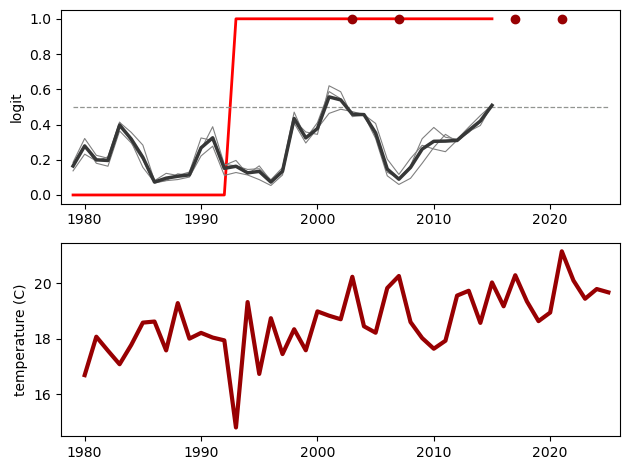

In [301]:
gridpointrecords = 1.*(np.copy(AllObs.recordtemps[10:]))
gridpointrecords[gridpointrecords==0] = np.nan

plt.subplot(2,1,1)
plt.plot(np.arange(1979,2016),np.transpose(obspredall),color='grey',label="CNN ensemble",linewidth=0.8,zorder=2)
plt.plot(np.arange(1979,2016),np.mean(obspredall,axis=0),color='xkcd:dark grey',label="CNN mean",linewidth=2.5,zorder=3)
plt.plot(np.arange(1979,2016),obsoutput,color='red',label='ground truth',linewidth=2,zorder=0)
plt.scatter(np.arange(1980,2026),gridpointrecords,color='xkcd:blood red',zorder=5)
plt.hlines(0.5,1979,2025,color='xkcd:grey',linestyle='dashed',label='decision boundary',linewidth=0.9)
plt.xlim(1978,2026)
plt.ylabel('logit')

plt.subplot(2,1,2)
plt.plot(np.arange(1980,2026),AllObs.outputsummer[10:]-273,color='xkcd:blood red',linewidth=3)
plt.xlim(1978,2026)
plt.ylabel('temperature (C)')

plt.tight_layout()

In [302]:
a=AllObs.recordtemps[10:]
a

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False,  True, False, False, False,  True, False, False, False,
       False])

In [303]:
AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)
alltrain, _, _ = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,-10,0) # need this to get the GMT vector
_, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2) # gmt vector
inputssptrain, _, _ = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,-20)

inputssptrain = np.round((inputssptrain.squeeze()+0.2)*10)

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/bin/DataHolder.py:940: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  endind = None


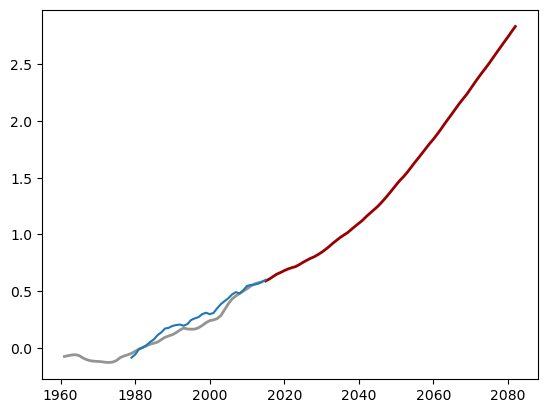

In [307]:
inputgrab = inputtrainGMT.squeeze().numpy()
inputgrabhist = inputgrab[(inputssptrain==0)]
inputgrabssp585 = inputgrab[inputssptrain==4]

inputhistreshape = np.reshape(inputgrabhist,(25,int(len(inputgrabhist)/25)))
inputssp585reshape = np.reshape(inputgrabssp585,(25,int(len(inputgrabssp585)/25)))

plt.plot(np.arange(1961,2015),np.mean(inputhistreshape,axis=0),color="xkcd:grey",linewidth=2)
plt.plot(np.arange(2015,2083),np.mean(inputssp585reshape,axis=0),color="xkcd:blood red",linewidth=2)
plt.plot(np.arange(1979,2016),obsinputgmt.squeeze())